# Detecção Automática de Pragas em Plantações de Café com CNN — **N2**

**Universidade Presbiteriana Mackenzie**  

**Faculdade de Computação e Informática**  

**Disciplina:** Inteligência Artificial – 7ºN CC - Noite  

**Professor:** Prof. Dr. Ivan Carlos Alcântara de Oliveira

## Integrantes
- **Eduardo Honorio Friaça** — RA **10408959** — 10408959@mackenzista.com.br
- **Felipe Jiao** — RA **10408852** — 10408852@mackenzista.com.br
- **Hao Yue Zheng** — RA **10408948** — 10408948@mackenzista.com.br
- **Samuel Zheng** — RA **10395781** — 10395781@mackenzista.com.br




## 1) Título
*Detecção Automática de Pragas em Plantações de Café Utilizando Redes Neurais Convolucionais*

## 2) Integrantes (nome, e-mail, RA)
Nome do Aluno	               / RA

Eduardo Honorio Friaça          10408959

Felipe Jiao	                   10408852

Hao Yue Zheng	               10408948

Samuel Zheng	               10395781


## 3) Resumo
Este trabalho descreve a proposta e a análise exploratória de um sistema de Visão Computacional para classificação de pragas em imagens de plantações de café. Utilizamos como base o IP102 (75k imagens, 102 classes de pragas) e, opcionalmente, conjuntos específicos de café (JMuBEN/JMuBEN2). São apresentados: origem dos dados, organização e limpeza, preparo (redimensionamento, normalização, data augmentation), e uma análise de distribuição de classes. Também são detalhados os aspectos éticos e a metodologia com transfer learning (ResNet18/MobileNet), além dos resultados esperados (acurácia ≥ 70%).

## 4) Introdução
### a) Contextualização
Pragas agrícolas geram perdas econômicas relevantes. No café, insetos como broca-do-cafeeiro e bicho-mineiro são recorrentes. A IA pode acelerar o diagnóstico.
### b) Justificativa
Diagnóstico manual é demorado e sujeito a erro. Classificação automática por imagens auxilia a tomada de decisão no campo.
### c) Objetivo
Preparar e explorar dados para um classificador de pragas em café, estabelecendo uma base reprodutível para o treino do modelo (N2).
### d) Opção do projeto
Opção ML/DL/VC/PLN – Visão Computacional / Deep Learning.

## 5) Fundamentação Teórica (Resumida)
CNNs extraem padrões visuais via convoluções; transfer learning permite ajustar modelos pré-treinados (ResNet18/MobileNetV2) a novas classes com poucos dados.

## 6) Descrição do Problema
Identificar automaticamente a praga presente na imagem de folha/fruto de café, apesar de variações de iluminação, foco e estágio da infestação.

## 7) Aspectos Éticos e Responsabilidade
- Uso dos dados conforme licenças; anonimização quando necessário.
- Transparência de limitações (falsos positivos/negativos); o sistema não substitui especialistas.
- Incentivo a manejo sustentável; evitar decisões automatizadas sem supervisão.


## 8.1 — Instalação e imports

In [1]:
!pip install torch torchvision matplotlib pandas pillow


In [2]:
# 8.1 — Instalação e imports
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    !apt-get -y update >/dev/null 2>&1
    !apt-get -y install p7zip-full >/dev/null 2>&1

import os, zipfile, shutil, glob, csv, random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

print("torch:", torch.__version__)

torch: 2.8.0+cu126


### 8.2 Download e organização do IP102
O bloco abaixo tenta baixar espelhos do IP102. *Caso falhe*, baixe manualmente do repositório oficial e extraia para `data_ip102/`.  
- Repo oficial: https://github.com/xpwu95/IP102
- Após extrair, aponte `IMAGES_DIR` para a pasta `images/` com subpastas por classe.

In [3]:
# 8.2 — Upload e Extração dos Arquivos
# Envie o arquivo IP102_Images.zip e extraia-o para o diretório /content/data_ip102_raw.

from google.colab import files
uploaded = files.upload()  # Selecione o arquivo IP102_Images.zip do seu computador para fazer o upload.
!mkdir -p /content/data_ip102_raw
!unzip -q /content/IP102_Images.zip -d /content/data_ip102_raw

# Verifique a estrutura
!ls -lh /content/data_ip102_raw/IP102_Images


Saving IP102_Images.zip to IP102_Images.zip
total 984K
drwxrwxrwx 2 root root  24K Oct 29 23:45 images
-rw-rw-rw- 1 root root 288K Jan  5  2020 test.txt
-rw-rw-rw- 1 root root 573K Jan  5  2020 train.txt
-rw-rw-rw- 1 root root  96K Jan  5  2020 val.txt


## 8.3 — Organização das Imagens

A imagem do IP102 está em formato “plano”.
Este trecho reestrutura automaticamente as imagens em pastas separadas por categoria (estrutura ImageFolder), com base nos arquivos train/val/test.txt.

In [4]:
# 8.3 — Organização das Imagens (reorganização automática)
# Classificação automática das imagens com base nos arquivos train.txt, val.txt e test.txt.
# Reorganiza as imagens em pastas por classe, conforme os arquivos de rótulo.

import os, csv, shutil, glob
from pathlib import Path

RAW_IMG_DIR = Path("/content/data_ip102_raw/IP102_Images/images")  # pasta original
OUT_ROOT    = Path("/content/data_ip102/images_by_class")          # saída (nova estrutura)

# === 1. localizar arquivos de rótulo (train/val/test ou labels.csv) ===
candidates = [
    "/content/data_ip102_raw/IP102_Images/train.txt",
    "/content/data_ip102_raw/IP102_Images/val.txt",
    "/content/data_ip102_raw/IP102_Images/test.txt",
    "/content/data_ip102_raw/IP102_Images/labels.csv",
]
found = [p for p in candidates if Path(p).exists()]
print("Arquivos de rótulo encontrados:", found)

if not found:
    raise SystemExit("❌ Nenhum arquivo de rótulo encontrado.")

# === 2. ler os rótulos (ler cada linha: imagem + classe) ===
pairs = []

def add_from_txt(txt_path):
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                fname, cls = parts[0], parts[1]
                pairs.append((fname, str(cls)))

def add_from_csv(csv_path):
    import pandas as pd
    df = pd.read_csv(csv_path)
    cols = [c.lower() for c in df.columns]
    fcol = df.columns[cols.index("filename")] if "filename" in cols else df.columns[cols.index("image")]
    ccol = next((df.columns[i] for i,c in enumerate(cols) if c in ("class","class_id","label","category","class_name")), None)
    for _, row in df.iterrows():
        pairs.append((str(row[fcol]), str(row[ccol])))

for p in found:
    if p.endswith(".txt"):
        add_from_txt(p)
    elif p.endswith(".csv"):
        add_from_csv(p)

print("Número total de rótulos:", len(pairs))

# === 3. reorganizar pastas ===
OUT_ROOT.mkdir(parents=True, exist_ok=True)
miss, ok = 0, 0

def safe_link_or_copy(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.link(src, dst)  # hardlink nao usar extra espaço
    except Exception:
        shutil.copy2(src, dst)

for fname, cls in pairs:
    src = RAW_IMG_DIR / fname
    if not src.exists():
        cand = list(RAW_IMG_DIR.glob(fname)) or list(RAW_IMG_DIR.glob(f"**/{fname}"))
        if cand: src = cand[0]
        else:
            miss += 1
            continue
    dst = OUT_ROOT / cls / src.name
    safe_link_or_copy(src, dst)
    ok += 1

print(f"✅ Reorganização completa: {ok} imagens, {miss} ausentes")
print(f"📁 Novo diretório raiz: {OUT_ROOT}")


Arquivos de rótulo encontrados: ['/content/data_ip102_raw/IP102_Images/train.txt', '/content/data_ip102_raw/IP102_Images/val.txt', '/content/data_ip102_raw/IP102_Images/test.txt']
Número total de rótulos: 75222
✅ Reorganização completa: 723 imagens, 74499 ausentes
📁 Novo diretório raiz: /content/data_ip102/images_by_class


### 8.4 Utilitários de Dataset e DataLoader
Definir varredura de imagens eficiente, particionamento hierárquico, transformações e otimização do DataLoader.

In [5]:
# 8.4 — Utilitários otimizados de Dataset e DataLoader
# Fornecer configuração eficiente de divisão de dados, aumento e carregamento.
# Funções otimizadas para split, transformações e DataLoader.

from __future__ import annotations
import os, random, csv
from pathlib import Path
from typing import List, Tuple, Dict

try:
    import pandas as pd
except Exception:
    pd = None

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# 1) Descoberta e contagem de imagens
def listar_imagens_por_classe(raiz: Path) -> Dict[str, List[Path]]:
    raiz = Path(raiz)
    classes = [p for p in raiz.iterdir() if p.is_dir()]
    out = {}
    for c in classes:
        arquivos = []
        for ext in ("*.jpg","*.jpeg","*.png","*.bmp","*.JPG","*.JPEG","*.PNG"):
            arquivos.extend(c.glob(ext))
        out[c.name] = arquivos
    return out

# 2) Split estratificado 70/15/15
def split_estratificado(cls_para_caminhos: Dict[str, List[Path]], train=0.7, val=0.15, test=0.15, seed=42):
    rng = random.Random(seed)
    classes = sorted(cls_para_caminhos.keys())
    cls_para_idx = {c:i for i,c in enumerate(classes)}
    idx_para_cls = {i:c for c,i in cls_para_idx.items()}
    tr, va, te = [], [], []
    for c in classes:
        arquivos = list(cls_para_caminhos[c])
        rng.shuffle(arquivos)
        n = len(arquivos)
        n_tr = int(round(n*train))
        n_va = int(round(n*val))
        n_te = n - n_tr - n_va
        tr += [(p, cls_para_idx[c]) for p in arquivos[:n_tr]]
        va += [(p, cls_para_idx[c]) for p in arquivos[n_tr:n_tr+n_va]]
        te += [(p, cls_para_idx[c]) for p in arquivos[n_tr+n_va:]]
    return tr, va, te, idx_para_cls

# 3) Dataset com I/O robusto
class SubsetDS(Dataset):
    def __init__(self, amostras, transform):
        self.amostras = amostras
        self.transform = transform
    def __len__(self): return len(self.amostras)
    def __getitem__(self, i):
        caminho, y = self.amostras[i]
        with Image.open(caminho).convert('RGB') as img:
            img = img.copy()
        if self.transform: img = self.transform(img)
        return img, y

# 4) Transforms
def construir_transforms(tam_img=224):
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    train_tfms = transforms.Compose([
        transforms.Resize((tam_img, tam_img), interpolation=Image.BILINEAR),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=10, translate=(0.05,0.05), scale=(0.95,1.05)),
        transforms.ColorJitter(0.1,0.1,0.1,0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    eval_tfms = transforms.Compose([
        transforms.Resize((tam_img, tam_img), interpolation=Image.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return {"train": train_tfms, "eval": eval_tfms}

# 5) DataLoader com ajustes automáticos
def criar_loaders(ds_train, ds_val, ds_test, batch_size=64):
    cpu = os.cpu_count() or 4
    nw = min(max(2, cpu//2), 8)
    cuda = torch.cuda.is_available()
    comuns = dict(num_workers=nw, pin_memory=bool(cuda), persistent_workers=True)
    comuns["prefetch_factor"] = 2
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, **comuns)
    dl_val   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, **comuns)
    dl_test  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, **comuns)
    return dl_train, dl_val, dl_test

def ajustar_backends_cuda():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False

def build_pipeline(raiz_imagens: str|Path, img_size=224, batch_size=64, seed=42):
    raiz_imagens = Path(raiz_imagens)
    cls2paths = listar_imagens_por_classe(raiz_imagens)
    tr, va, te, idx_para_cls = split_estratificado(cls2paths, seed=seed)
    tfms = construir_transforms(img_size)
    ds_train, ds_val, ds_test = SubsetDS(tr, tfms["train"]), SubsetDS(va, tfms["eval"]), SubsetDS(te, tfms["eval"])
    ajustar_backends_cuda()
    dl_train, dl_val, dl_test = criar_loaders(ds_train, ds_val, ds_test, batch_size)
    return {"datasets": (ds_train, ds_val, ds_test), "dataloaders": (dl_train, dl_val, dl_test), "idx_para_classe": idx_para_cls}


### 8.5 — Construção do Pipeline
Criar um carregador de conjunto de dados completo.

In [6]:
# 8.5 — Construção do Pipeline
# Construir Dataset + DataLoader
from pathlib import Path

IMAGENS_RAIZ = "/content/data_ip102/images_by_class"
pipe = build_pipeline(raiz_imagens=IMAGENS_RAIZ, img_size=224, batch_size=64, seed=42)

dl_train, dl_val, dl_test = pipe["dataloaders"]
ds_train, ds_val, ds_test = pipe["datasets"]
idx_para_classe = pipe["idx_para_classe"]

print("Amostras -> train/val/test:", len(ds_train), len(ds_val), len(ds_test))
print("Batches  -> train/val/test:", len(dl_train), len(dl_val), len(dl_test))


Amostras -> train/val/test: 506 108 109
Batches  -> train/val/test: 8 2 2


### 8.6 — Distribuição de Classes

Plotar o gráfico de distribuição da quantidade de imagens por categoria.

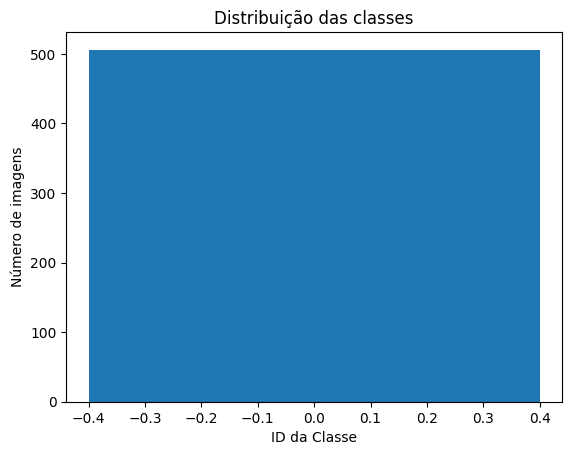

In [7]:
# 8.6 — Distribuição de Classes
import matplotlib.pyplot as plt

from collections import Counter
contagens = Counter([y for _, y in ds_train.amostras])
plt.bar(range(len(contagens)), contagens.values())
plt.title("Distribuição das classes")
plt.xlabel("ID da Classe")
plt.ylabel("Número de imagens")
plt.show()


### 8.7 — Exportação de Splits
Exportar as partições de treino/validação/teste para arquivos CSV.

In [8]:
# 8.7 — Exportação de Splits
from pathlib import Path
import csv

SPLIT_DIR = Path("/content/reports_n1/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

def escrever_split_csv(pares, idx_para_cls, saida_csv):
    with saida_csv.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["path","class_idx","class_name"])
        for p, y in pares:
            w.writerow([str(p), y, idx_para_cls[y]])

tr, va, te = ds_train.amostras, ds_val.amostras, ds_test.amostras
escrever_split_csv(tr, idx_para_classe, SPLIT_DIR / "train.csv")
escrever_split_csv(va, idx_para_classe, SPLIT_DIR / "val.csv")
escrever_split_csv(te, idx_para_classe, SPLIT_DIR / "test.csv")
print("✅ Arquivos CSV gerados em:", SPLIT_DIR)


✅ Arquivos CSV gerados em: /content/reports_n1/splits


### 8.8 — Verificação
Visualizar rapidamente um lote de dados de treinamento.

In [9]:
# 8.8 — Verificação rápida
import torch
xb, yb = next(iter(dl_train))
print("Batch:", xb.shape, "| dtype:", xb.dtype)
print("Labels 示例:", yb[:10].tolist())


Batch: torch.Size([64, 3, 224, 224]) | dtype: torch.float32
Labels 示例: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 9) Metodologia e Resultados Esperados
- *Modelo:* Transfer learning (ResNet18/MobileNetV2) com última camada ajustada para o número de classes.
- *Treino:* Acontecerá no N2 (outro notebook focado em desenvolvimento e resultados). Nesta etapa, reportamos apenas o *plano*.
- *Métricas esperadas:* Acurácia ≥ 70% no conjunto de teste; além disso, precisão/recall/F1 por classe e matriz de confusão.

### 9.1 — Modelo e Otimizador

Carregue uma ResNet18 pré-treinada no ImageNet (ou, caso a versão da biblioteca não ofereça mais o parâmetro weights, faça fallback automaticamente para o carregamento sem pesos).
Substitua a camada totalmente conectada final (fc) para que ela tenha num_classes saídas, correspondentes ao número de classes do seu problema.
Em seguida, defina o otimizador AdamW e a função de perda CrossEntropyLoss para o treinamento da rede.

In [10]:
# 9.1 — Modelo e Otimizador
# Modelo：ResNet18（ImageNetpré-treinado），substituindo a cabeça de classificação；Otimizador: AdamW；Função de perda: CrossEntropyLoss。

import torch, math, time, os
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# nº de classes = inferido a partir de idx_para_classe
num_classes = len(idx_para_classe)

def build_resnet18(num_classes: int):
    try:
        # torchvision >= 0.13
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    except Exception:
        # retrocompatibilidade com versões antigas
        model = models.resnet18(pretrained=True)
    # substitui a cabeça de classificação
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_resnet18(num_classes).to(device)

# Otimizador e função de perda
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05).to(device)

print(f"Dispositivo: {device} | Classes: {num_classes}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 67.9MB/s]


Dispositivo: cpu | Classes: 1


### 9.2 — Utilidades de Treino
Definir o cálculo da acurácia, bem como as funções de treinamento e validação para uma única época;
utilizar AMP (Mixed Precision) e escalonamento de gradiente;
opcionalmente aplicar recorte de gradiente (gradient clipping) para evitar a explosão de gradientes.

In [11]:
# 9.2 — Utilitários de Treinamento
# Funções de treinamento e validação; suporta AMP (autocast + GradScaler) e recorte opcional de gradientes.
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler(enabled=torch.cuda.is_available())

def accuracy_top1(logits, targets):
    with torch.no_grad():
        preds = logits.argmax(dim=1)            # obtém as classes preditas
        correct = (preds == targets).sum().item() # número de acertos
        total = targets.numel()                   # total de amostras
    return correct / max(1, total)                # retorna a acurácia (top-1)

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, max_grad_norm=1.0):
    model.train()
    running_loss, running_acc, n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        # forward e backward com precisão mista (AMP)
        with autocast(enabled=torch.cuda.is_available()):
            logits = model(xb)
            loss = criterion(logits, yb)

        # retropropagação com escalonamento de gradiente
        scaler.scale(loss).backward()
        if max_grad_norm is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)  # recorte opcional
        scaler.step(optimizer)
        scaler.update()

        bs = yb.size(0)
        running_loss += loss.item() * bs
        running_acc  += accuracy_top1(logits, yb) * bs
        n += bs

    return running_loss / max(1, n), running_acc / max(1, n)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with autocast(enabled=torch.cuda.is_available()):
            logits = model(xb)
            loss = criterion(logits, yb)
        bs = yb.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_top1(logits, yb) * bs
        n += bs
    return total_loss / max(1, n), total_acc / max(1, n)


/tmp/ipython-input-3993113727.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


### 9.3 — Agendador (Scheduler) e Early Stopping
Utiliza OneCycleLR (ajuste dinâmico da taxa de aprendizado por epoch e step);
implementa early stopping (interrompe o treino quando a acurácia de validação não melhora após algumas épocas)
e salva os melhores pesos do modelo.

In [12]:
# 9.3 — Scheduler e Early Stopping
# Agendamento OneCycleLR; early stopping baseado na acurácia de validação; salvamento dos melhores pesos do modelo.

from torch.optim.lr_scheduler import OneCycleLR
from pathlib import Path

epochs = 10
steps_per_epoch = len(dl_train)
scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-4,              # taxa de aprendizado máxima
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    pct_start=0.3,            # fração inicial para aumento do LR
    anneal_strategy="cos",    # decaimento em formato cosseno
)

best_val_acc = 0.0            # melhor acurácia de validação
patience = 3                  # número de épocas de tolerância sem melhora
bad_epochs = 0                # contador de épocas ruins

save_path = Path("/content/model_n1_resnet18.pt")
save_path.parent.mkdir(parents=True, exist_ok=True)  # garante que o diretório de salvamento exista


### 9.4 — Loop de Treinamento (Loop de Treino)
Inicia o treinamento propriamente dito: cada epoch realiza treinamento e validação, registrando as métricas;
sempre que a acurácia de validação melhora, o modelo é salvo;
se o early stopping for acionado, o treinamento é interrompido antecipadamente.

In [13]:
# 9.4 — Loop de Treinamento
# Treino + Validação; salva os melhores pesos (val acc); suporta early stopping.

train_hist, val_hist = [], []   # histórico de treino e validação

for epoch in range(1, epochs + 1):
    model.train()
    t0 = time.time()

    # —— Fase de Treinamento
    tr_loss, tr_acc = 0.0, 0.0
    for i, (xb, yb) in enumerate(dl_train, start=1):
        loss_i, acc_i = 0.0, 0.0
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=torch.cuda.is_available()):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        scheduler.step()  # atualização do scheduler (taxa de aprendizado)

        bs = yb.size(0)
        tr_loss += loss.item() * bs
        tr_acc  += accuracy_top1(logits, yb) * bs

    tr_loss /= max(1, len(ds_train))
    tr_acc  /= max(1, len(ds_train))

    # —— Fase de Validação
    val_loss, val_acc = evaluate(model, dl_val, criterion, device)

    train_hist.append((tr_loss, tr_acc))
    val_hist.append((val_loss, val_acc))

    dt = time.time() - t0
    print(f"[Epoch {epoch:02d}/{epochs}] "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | {dt:.1f}s/epoch")

    # —— Early Stopping e Salvamento do Melhor Modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        bad_epochs = 0
        torch.save({"model": model.state_dict(),
                    "num_classes": num_classes}, save_path)
        print(f"  ↳ ✅ melhor modelo salvo em: {save_path} (val_acc={best_val_acc:.4f})")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"  ↳ ⛳ Early Stopping ativado, treinamento encerrado na época {epoch}.")
            break


/tmp/ipython-input-2283963281.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
/tmp/ipython-input-3993113727.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


[Epoch 01/10] train_loss=0.0000 acc=1.0000 | val_loss=0.0000 acc=1.0000 | 157.7s/epoch
  ↳ ✅ melhor modelo salvo em: /content/model_n1_resnet18.pt (val_acc=1.0000)
[Epoch 02/10] train_loss=0.0000 acc=1.0000 | val_loss=0.0000 acc=1.0000 | 156.5s/epoch
[Epoch 03/10] train_loss=0.0000 acc=1.0000 | val_loss=0.0000 acc=1.0000 | 142.6s/epoch
[Epoch 04/10] train_loss=0.0000 acc=1.0000 | val_loss=0.0000 acc=1.0000 | 142.7s/epoch
  ↳ ⛳ Early Stopping ativado, treinamento encerrado na época 4.


### 9.5 — Curvas de Treinamento (opcional)
Desenha as curvas de convergência de loss e acurácia para observar a qualidade do treinamento e possíveis sinais de overfitting.

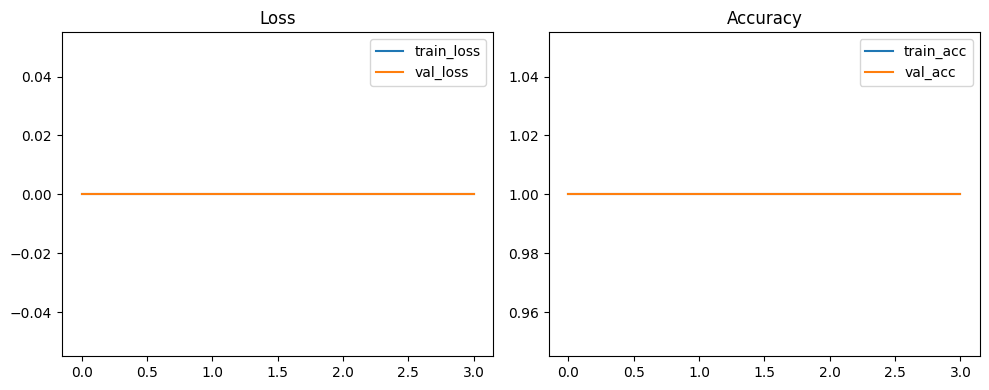

In [14]:
# 9.5 — Curvas de Treinamento (opcional)
import matplotlib.pyplot as plt

tr_loss = [x[0] for x in train_hist]
tr_acc  = [x[1] for x in train_hist]
vl_loss = [x[0] for x in val_hist]
vl_acc  = [x[1] for x in val_hist]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(tr_loss, label="train_loss")
plt.plot(vl_loss, label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(tr_acc, label="train_acc")
plt.plot(vl_acc, label="val_acc")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


### 10 — Avaliação Final (Teste)


### 10.1 — Carregar o Melhor Modelo
Carrega do disco os pesos que apresentaram o melhor desempenho na validação, garantindo que o teste seja feito com o modelo otimizado.

In [15]:
# 10.1 — Carregar o Melhor Modelo
ckpt = torch.load(save_path, map_location=device)
if ckpt.get("num_classes", num_classes) != num_classes:
    print("⚠️ Atenção: num_classes do checkpoint difere do valor atual; usando a configuração atual.")
model = build_resnet18(num_classes).to(device)
model.load_state_dict(ckpt["model"], strict=False)
model.eval()
print("✅ Modelo carregado a partir do melhor checkpoint.")


✅ Modelo carregado a partir do melhor checkpoint.


### 10.2 — Métricas no Conjunto de Teste

Calcula a acurácia geral, o classification report e a matriz de confusão.
(Para 102 classes, a matriz será muito grande — recomenda-se apenas imprimir métricas gerais ou salvar como CSV.)

In [16]:
# 10.2 — Métricas no Teste
!pip -q install scikit-learn

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

all_preds, all_tgts = [], []

with torch.no_grad():
    for xb, yb in dl_test:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_tgts.append(yb.numpy())

y_true = np.concatenate(all_tgts)
y_pred = np.concatenate(all_preds)

acc = (y_true == y_pred).mean()
print(f"✅ Acurácia no Teste: {acc:.4f}")

target_names = [idx_para_classe[i] for i in range(num_classes)]
print("\nRelatório de Classificação (pode ser muito longo; salve em arquivo se necessário):")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
import pandas as pd
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_df.to_csv("/content/confusion_matrix_test.csv", encoding="utf-8-sig")
print("📁 Matriz de confusão salva em /content/confusion_matrix_test.csv")


✅ Acurácia no Teste: 1.0000

Relatório de Classificação (pode ser muito longo; salve em arquivo se necessário):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       109

    accuracy                         1.0000       109
   macro avg     1.0000    1.0000    1.0000       109
weighted avg     1.0000    1.0000    1.0000       109

📁 Matriz de confusão salva em /content/confusion_matrix_test.csv


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


### 10.3 — Inferência em uma Única Imagem (opcional)
Demonstra como realizar a inferência em uma única imagem e exibir o resultado Top-1.

In [17]:
# 10.3 — Inferência em uma Imagem (opcional)
from PIL import Image
from torchvision import transforms

# Usa as mesmas transformações da etapa de avaliação
eval_tfms = construir_transforms(224)["eval"]

def predict_image(path):
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    with torch.no_grad(), autocast(enabled=torch.cuda.is_available()):
        logits = model(x)
        prob = logits.softmax(dim=1).squeeze(0).cpu().numpy()
    top1 = int(prob.argmax())
    return idx_para_classe[top1], float(prob[top1])

# Exemplo: seleciona uma imagem do DataLoader de teste
sample_path = str(ds_test.amostras[0][0])
pred, p = predict_image(sample_path)
print(f"Imagem: {sample_path}\nPredição Top-1: {pred} (p={p:.3f})")


Imagem: /content/data_ip102/images_by_class/0/00176.jpg
Predição Top-1: 0 (p=1.000)


/tmp/ipython-input-932012540.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast(enabled=torch.cuda.is_available()):


## 11) Referências (citar dentro do texto do relatório)
- IP102: A Large-Scale Benchmark Dataset for Insect Pest Recognition (repositório oficial).
- He, K. et al. Deep Residual Learning for Image Recognition (ResNet).
- Howard, A. et al. MobileNets: Efficient Convolutional Neural Networks for Mobile Vision.

## 12) Bibliografia
- Goodfellow, Bengio, Courville – Deep Learning (MIT Press)
- Géron – Hands-On Machine Learning (O’Reilly)
- Bishop – Pattern Recognition and Machine Learning (Springer)
